In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score
from sklearn.naive_bayes import MultinomialNB

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

COLORS = {
    'real': '#1D9E75',
    'fake': '#E24B4A'
}

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv('Fake.csv')

df_true['label'] = 1
df_fake['label'] = 0

df = pd.concat([df_true, df_fake], ignore_index=True)

df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df = df[df['content'].str.strip().str.len() > 10]

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (44898, 6)


,title,text,subject,date,label,content
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,"As U.S. budget fight looms, Republicans flip t..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,U.S. military to accept transgender recruits o...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1,FBI Russia probe helped by Australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1,Trump wants Postal Service to charge 'much mor...


In [ ]:
def plot_eda(df):
    print("Generating EDA plots...")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1. Class distribution
    counts = df['label'].value_counts()
    axes[0].bar(['Fake', 'Real'], [counts[0], counts[1]],
                color=[COLORS['fake'], COLORS['real']])
    axes[0].set_title('Class Distribution')

    # 2. Word count
    df['word_count'] = df['content'].str.split().str.len()
    axes[1].hist(df[df['label']==0]['word_count'], alpha=0.5, label='Fake')
    axes[1].hist(df[df['label']==1]['word_count'], alpha=0.5, label='Real')
    axes[1].legend()
    axes[1].set_title('Word Count')

    # 3. Subject (if exists)
    if 'subject' in df.columns:
        df.groupby(['subject','label']).size().unstack().plot(kind='barh', ax=axes[2])
        axes[2].set_title('Subjects')
    else:
        axes[2].text(0.5,0.5,'No subject column', ha='center')

    plt.tight_layout()
    plt.show()

Generating EDA plots...


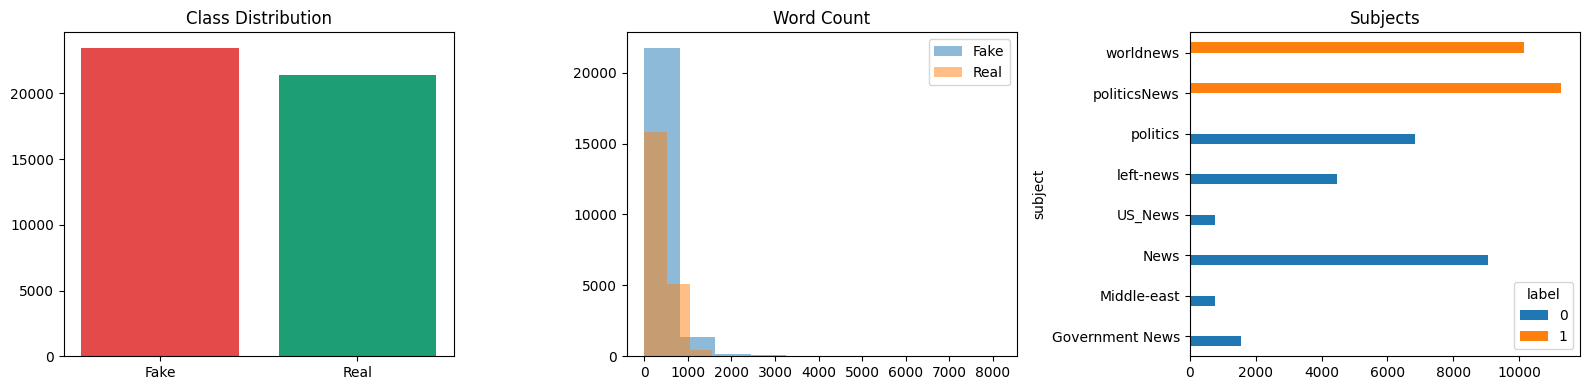

In [ ]:
plot_eda(df)

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [LEMMATIZER.lemmatize(w) for w in words if w not in STOP_WORDS]
    return " ".join(words)

df['cleaned'] = df['content'].apply(clean_text)

In [ ]:
X = df['cleaned']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
bow = CountVectorizer(max_features=5000)
X0_train = bow.fit_transform(X_train)
X0_test = bow.transform(X_test)

In [ ]:
bow_clean = CountVectorizer(max_features=5000)
X1_train = bow_clean.fit_transform(X_train)
X1_test = bow_clean.transform(X_test)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X2_train = tfidf.fit_transform(X_train)
X2_test = tfidf.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

In [ ]:
def evaluate(X_tr, X_te, y_tr, y_te):
    results = {}

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        acc = accuracy_score(y_te, pred)
        f1 = f1_score(y_te, pred)

        results[name] = (acc, f1)
        print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}")

    return results

In [ ]:
print("Stage 0 (Raw BoW)")
res0 = evaluate(X0_train, X0_test, y_train, y_test)

print("\nStage 1 (Cleaned BoW)")
res1 = evaluate(X1_train, X1_test, y_train, y_test)

print("\nStage 2 (TF-IDF)")
res2 = evaluate(X2_train, X2_test, y_train, y_test)

Stage 0 (Raw BoW)
Logistic Regression: Accuracy=0.9952, F1=0.9950
Naive Bayes: Accuracy=0.9501, F1=0.9478

Stage 1 (Cleaned BoW)
Logistic Regression: Accuracy=0.9952, F1=0.9950
Naive Bayes: Accuracy=0.9501, F1=0.9478

Stage 2 (TF-IDF)
Logistic Regression: Accuracy=0.9881, F1=0.9876
Naive Bayes: Accuracy=0.9334, F1=0.9301


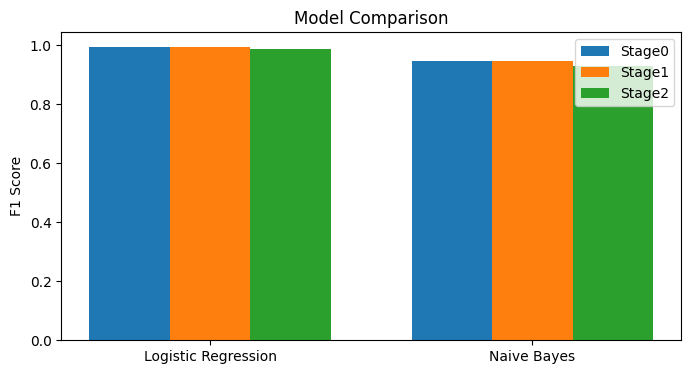

In [ ]:
labels = list(models.keys())

stage0 = [res0[m][1] for m in labels]
stage1 = [res1[m][1] for m in labels]
stage2 = [res2[m][1] for m in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,4))
plt.bar(x, stage0, width, label='Stage0')
plt.bar(x+width, stage1, width, label='Stage1')
plt.bar(x+2*width, stage2, width, label='Stage2')

plt.xticks(x+width, labels)
plt.ylabel("F1 Score")
plt.title("Model Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import PassiveAggressiveClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": LinearSVC(),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000)
}

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate(X_tr, X_te, y_tr, y_te):
    results = {}

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        acc = accuracy_score(y_te, pred)
        f1 = f1_score(y_te, pred)
        prec = precision_score(y_te, pred)
        rec = recall_score(y_te, pred)

        results[name] = (acc, f1, prec, rec)

        print(f"{name}")
        print(f"  Accuracy : {acc:.4f}")
        print(f"  F1 Score : {f1:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall   : {rec:.4f}")
        print("-"*30)

    return results

In [ ]:
print("Stage 2 (TF-IDF)")
res2 = evaluate(X2_train, X2_test, y_train, y_test)

Stage 2 (TF-IDF)
Logistic Regression
  Accuracy : 0.9881
  F1 Score : 0.9876
  Precision: 0.9845
  Recall   : 0.9907
------------------------------
Naive Bayes
  Accuracy : 0.9334
  F1 Score : 0.9301
  Precision: 0.9310
  Recall   : 0.9293
------------------------------
Decision Tree
  Accuracy : 0.9957
  F1 Score : 0.9955
  Precision: 0.9944
  Recall   : 0.9965
------------------------------
Random Forest
  Accuracy : 0.9986
  F1 Score : 0.9985
  Precision: 0.9988
  Recall   : 0.9981
------------------------------
SVM
  Accuracy : 0.9940
  F1 Score : 0.9937
  Precision: 0.9932
  Recall   : 0.9942
------------------------------
Passive Aggressive
  Accuracy : 0.9945
  F1 Score : 0.9943
  Precision: 0.9946
  Recall   : 0.9939
------------------------------


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion(model, X_te, y_te):
    pred = model.predict(X_te)
    cm = confusion_matrix(y_te, pred)

    disp = ConfusionMatrixDisplay(cm, display_labels=['Fake','Real'])
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

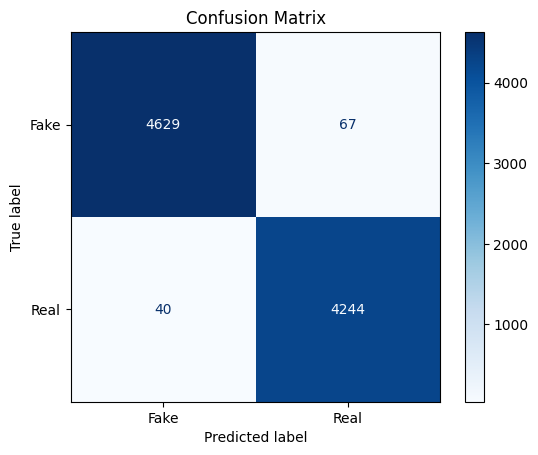

In [ ]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X2_train, y_train)

plot_confusion(best_model, X2_test, y_test)

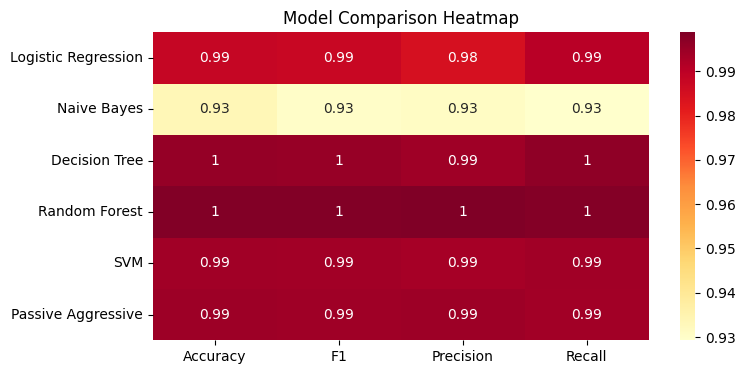

In [ ]:
import pandas as pd

df_results = pd.DataFrame(res2).T
df_results.columns = ['Accuracy','F1','Precision','Recall']

plt.figure(figsize=(8,4))
sns.heatmap(df_results, annot=True, cmap='YlOrRd')
plt.title("Model Comparison Heatmap")
plt.show()

In [ ]:
print("Stage 0")
res0 = evaluate(X0_train, X0_test, y_train, y_test)

print("Stage 1")
res1 = evaluate(X1_train, X1_test, y_train, y_test)

print("Stage 2")
res2 = evaluate(X2_train, X2_test, y_train, y_test)

Stage 0
Logistic Regression
  Accuracy : 0.9952
  F1 Score : 0.9950
  Precision: 0.9958
  Recall   : 0.9942
------------------------------
Naive Bayes
  Accuracy : 0.9501
  F1 Score : 0.9478
  Precision: 0.9469
  Recall   : 0.9486
------------------------------
Decision Tree
  Accuracy : 0.9964
  F1 Score : 0.9963
  Precision: 0.9956
  Recall   : 0.9970
------------------------------
Random Forest
  Accuracy : 0.9987
  F1 Score : 0.9986
  Precision: 0.9986
  Recall   : 0.9986
------------------------------
SVM
  Accuracy : 0.9945
  F1 Score : 0.9943
  Precision: 0.9949
  Recall   : 0.9937
------------------------------
Passive Aggressive
  Accuracy : 0.9931
  F1 Score : 0.9928
  Precision: 0.9944
  Recall   : 0.9911
------------------------------
Stage 1
Logistic Regression
  Accuracy : 0.9952
  F1 Score : 0.9950
  Precision: 0.9958
  Recall   : 0.9942
------------------------------
Naive Bayes
  Accuracy : 0.9501
  F1 Score : 0.9478
  Precision: 0.9469
  Recall   : 0.9486
------------

In [ ]:
labels = list(models.keys())

stage0 = [res0[m][1] for m in labels]
stage1 = [res1[m][1] for m in labels]
stage2 = [res2[m][1] for m in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x, stage0, width, label='BoW Raw')
plt.bar(x+width, stage1, width, label='BoW Clean')
plt.bar(x+2*width, stage2, width, label='TF-IDF')

plt.xticks(x+width, labels, rotation=20)
plt.ylabel("F1 Score")
plt.legend()
plt.title("Ablation Study")
plt.show()

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english',
    sublinear_tf=True
)

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()

    words = [
        LEMMATIZER.lemmatize(w)
        for w in words
        if w not in STOP_WORDS and len(w) > 2
    ]

    return " ".join(words)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Decision Tree": DecisionTreeClassifier(max_depth=30),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": LinearSVC(class_weight='balanced'),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=2000)
}

In [ ]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

In [ ]:
best_model = None
best_score = 0

for name, model in models.items():
    model.fit(X2_train, y_train)
    pred = model.predict(X2_test)

    f1 = f1_score(y_test, pred)

    if f1 > best_score:
        best_score = f1
        best_model = (name, model)

print("Best Model:", best_model[0])
print("Best F1 Score:", best_score)

In [ ]:
def extra_features(texts):
    features = []

    for t in texts:
        t = str(t)
        words = t.split()

        length = len(words)
        exclam = t.count('!')
        caps = sum(1 for c in t if c.isupper())

        features.append([length, exclam, caps])

    return np.array(features)

In [ ]:
from scipy.sparse import hstack

extra_train = extra_features(X_train)
extra_test = extra_features(X_test)

X2_train = hstack([X2_train, extra_train])
X2_test = hstack([X2_test, extra_test])

In [ ]:
from xgboost import XGBClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Decision Tree": DecisionTreeClassifier(max_depth=30),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": LinearSVC(class_weight='balanced'),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=2000),


    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='logloss',
        use_label_encoder=False
    )
}

In [ ]:
from sklearn.metrics import roc_curve, auc
def plot_roc_curve(models, X_test, y_test):
    plt.figure(figsize=(8,6))

    for name, model in models.items():

        # Some models don't have predict_proba (like SVM)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:,1]
        else:
            y_score = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    plt.plot([0,1],[0,1],'k--')  # diagonal line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.show()

In [ ]:
trained_models = {}

for name, model in models.items():
    model.fit(X2_train, y_train)
    trained_models[name] = model

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:04:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


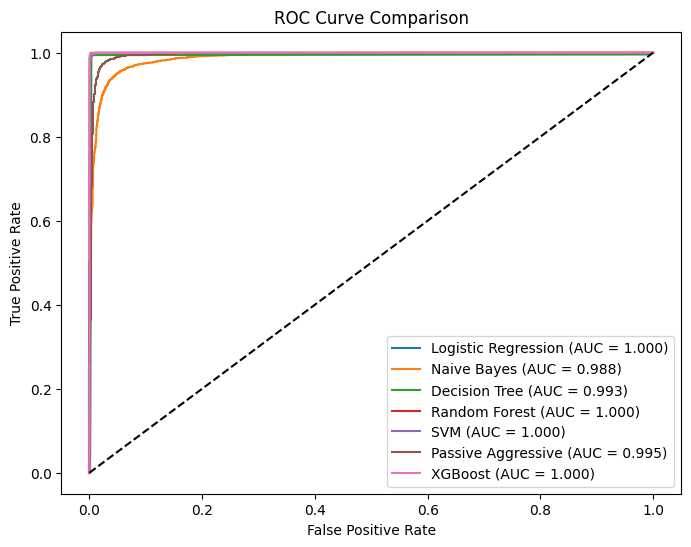

In [ ]:
plot_roc_curve(trained_models, X2_test, y_test)

In [ ]:
def extract_features(texts):
    features = []

    for t in texts:
        t = str(t)
        words = t.split()

        n_words = len(words) if len(words) > 0 else 1

        # features
        exclam = t.count('!')
        question = t.count('?')
        caps = sum(1 for c in t if c.isupper())
        avg_word_len = np.mean([len(w) for w in words]) if words else 0
        unique_ratio = len(set(words)) / n_words

        features.append([
            exclam,
            question,
            caps,
            avg_word_len,
            unique_ratio
        ])

    return np.array(features)

In [ ]:
extra_train = extract_features(X_train)
extra_test = extract_features(X_test)

In [ ]:
from scipy.sparse import hstack

X3_train = hstack([X2_train, extra_train])
X3_test = hstack([X2_test, extra_test])

In [ ]:
print("Stage 3 (TF-IDF + Domain Features)")
res3 = evaluate(X3_train, X3_test, y_train, y_test)

Stage 3 (TF-IDF + Domain Features)
Logistic Regression
  Accuracy : 0.9943
  F1 Score : 0.9941
  Precision: 0.9926
  Recall   : 0.9956
------------------------------
Naive Bayes
  Accuracy : 0.9499
  F1 Score : 0.9477
  Precision: 0.9442
  Recall   : 0.9512
------------------------------
Decision Tree
  Accuracy : 0.9958
  F1 Score : 0.9956
  Precision: 0.9960
  Recall   : 0.9951
------------------------------
Random Forest
  Accuracy : 0.9987
  F1 Score : 0.9986
  Precision: 0.9988
  Recall   : 0.9984
------------------------------
SVM
  Accuracy : 0.9954
  F1 Score : 0.9952
  Precision: 0.9942
  Recall   : 0.9963
------------------------------
Passive Aggressive
  Accuracy : 0.9683
  F1 Score : 0.9659
  Precision: 0.9902
  Recall   : 0.9428
------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:10:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
  Accuracy : 0.9979
  F1 Score : 0.9978
  Precision: 0.9977
  Recall   : 0.9979
------------------------------


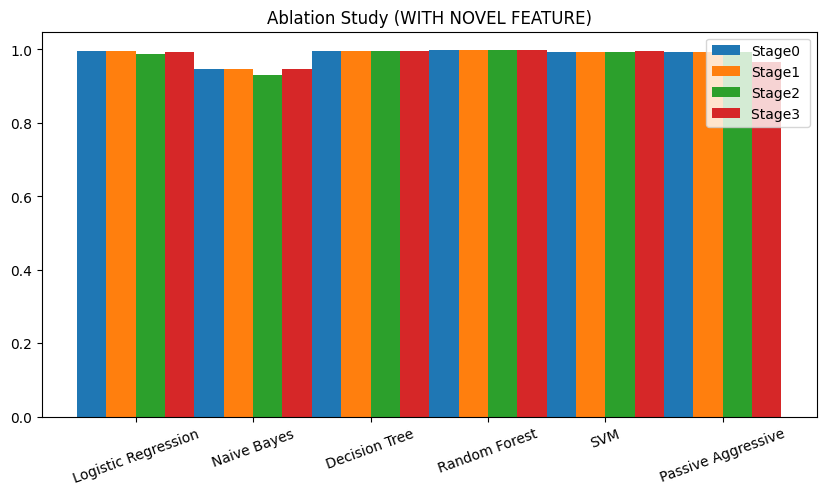

In [ ]:
stage3 = [res3[m][1] for m in labels]

plt.figure(figsize=(10,5))
plt.bar(x, stage0, width, label='Stage0')
plt.bar(x+width, stage1, width, label='Stage1')
plt.bar(x+2*width, stage2, width, label='Stage2')
plt.bar(x+3*width, stage3, width, label='Stage3 ')

plt.xticks(x+width*1.5, labels, rotation=20)
plt.legend()
plt.title("Ablation Study (WITH NOVEL FEATURE)")
plt.show()

In [ ]:
best_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss'
)

best_model.fit(X3_train, y_train)
pred = best_model.predict(X3_test)

print("Final Accuracy:", accuracy_score(y_test, pred))
print("Final F1 Score:", f1_score(y_test, pred))

Final Accuracy: 0.9978841870824053
Final F1 Score: 0.9977827050997783


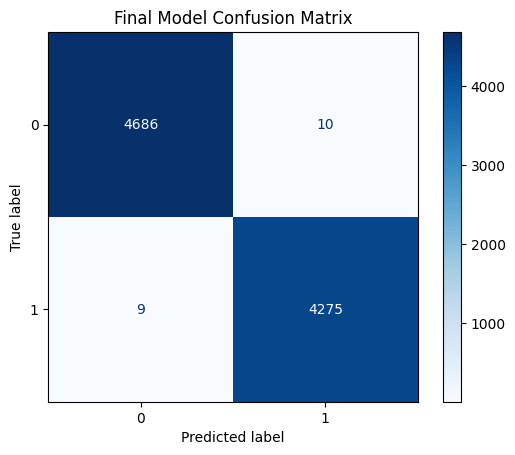

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='Blues')
plt.title("Final Model Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

results = {
    "Accuracy": accuracy_score(y_test, pred),
    "F1": f1_score(y_test, pred)
}

pd.DataFrame([results]).to_csv("final_results.csv", index=False)